In [1]:
%load_ext cuml.accel

In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score,recall_score,precision_recall_curve
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from itertools import product


In [4]:
df = pd.read_csv("Model_data_creditcard.csv")

In [63]:
X = df.drop(columns="Class",axis=1)
y = df["Class"]

scaler = StandardScaler()
X_scaler = pd.DataFrame(scaler.fit_transform(X),columns=X.columns)

In [65]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.3)

In [66]:
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [67]:
def param_tunning(model_class, param_list, params_name,metric='f1',threshold=0.5 ):
    test_param = [list(p) for p in product(*param_list)]
    score = []
    best_score = 0
    best_estimator = None
    best_param = None
    
    for params in test_param:
        kwargs = dict(zip(params_name, params))
        model = model_class(**kwargs)
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        if metric == 'recall':
            score = recall_score(y_test, y_pred)
        elif metric == 'f1':
            score = f1_score(y_test, y_pred)
        else:
            raise ValueError("metric must be 'recall' or 'f1'")

        if score > best_score:
            best_score = score
            best_estimator = model
            best_param = kwargs

    print(f"Best params: {best_param}")
    print(f"Best {metric}: {best_score:.4f}")

    return best_estimator

In [ ]:
param_list = [
    [150, 200],      
    [3, 4],          
    [0.01, 0.05],     
    [0.7, 0.8],       
    [0.6, 0.8],       
    [1, 5],           
    [0, 0.2]          
]

params_name = [
    'n_estimators',
    'max_depth',
    'learning_rate',
    'subsample',
    'colsample_bytree', # Crucial for preventing feature dominance
    'min_child_weight', # Crucial for noisy data
    'gamma'             # Conservative tree pruning
]

model_xgb = param_tunning(
    model_class=xgb.XGBClassifier,
    param_list=param_list,
    params_name=params_name,
    metric='f1',
    threshold=0.3,        # RẤT QUAN TRỌNG
)

Best params: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0}
Best f1: 0.8947


In [69]:
y_pred_proba = model_xgb.predict_proba(X_test)
y_pred = model_xgb.predict(X_test)

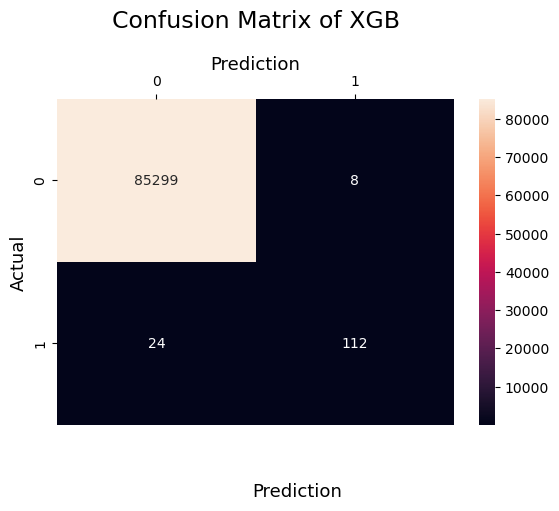

In [70]:
confusion_xgb = confusion_matrix(y_test,y_pred)
sns.heatmap(confusion_xgb, 
            annot=True,
            fmt='g', 
            xticklabels=['0','1'],
            yticklabels=['0','1'])
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix of XGB', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()

In [ ]:

param_list = [
    [150, 200],         
    [6, 10],            
    [2, 5],             
    [10, 20],           
    ['sqrt', 0.5],      
    [0.6, 0.8],         
    [True]             
]

params_name = [
    'n_estimators',
    'max_depth',
    'min_samples_leaf',   
    'min_samples_split', 
    'max_features',       
    'max_samples',        
    'bootstrap'
]

model_rf = param_tunning(
    model_class=RandomForestClassifier,
    param_list=param_list,
    params_name=params_name,
    metric='f1',
    threshold=0.3
)

Best params: {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'max_features': 0.5, 'max_samples': 0.8, 'bootstrap': True}
Best f1: 0.8839


In [72]:
y_pred_proba_rf = model_rf.predict_proba(X_test)
y_pred_rf = model_rf.predict(X_test)
y_pred_rd_all = model_rf.predict(X)

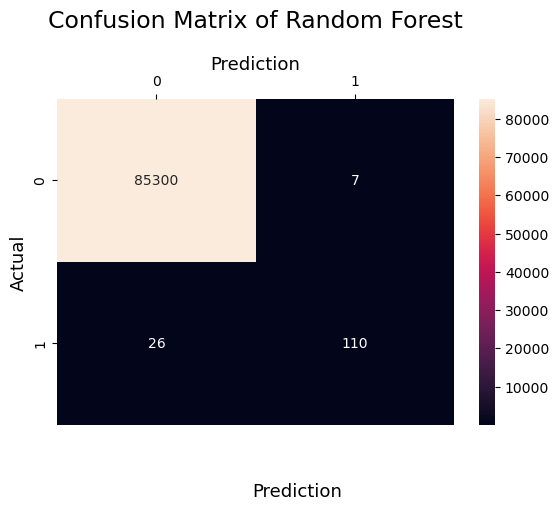

In [73]:
confusion_xgb = confusion_matrix(y_test,y_pred_rf)
sns.heatmap(confusion_xgb, 
            annot=True,
            fmt='g', 
            xticklabels=['0','1'],
            yticklabels=['0','1'])
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix of Random Forest', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()

Best threshold for RF (PR Curve): 0.4174, F1: 0.8880
Best threshold for XGB (PR Curve): 0.3189, F1: 0.8947


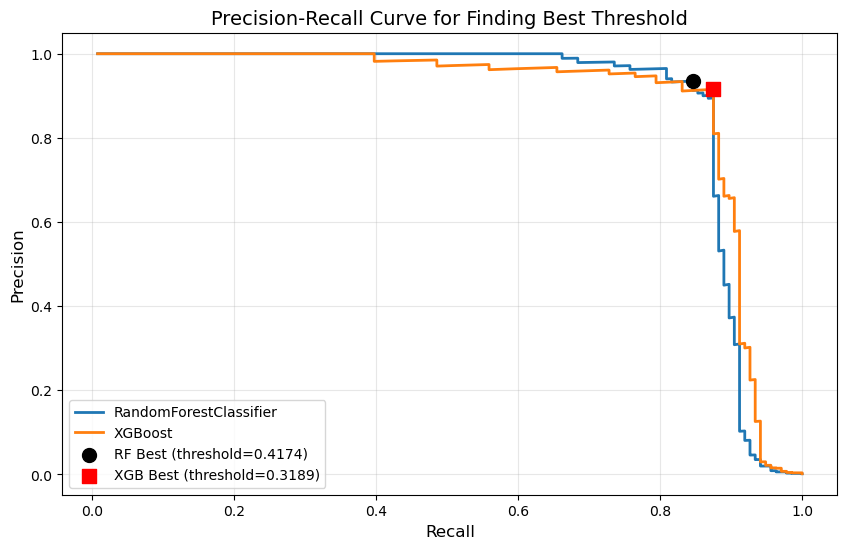

In [74]:

precision_rf, recall_rf, threshold_pr_rf = precision_recall_curve(y_test, y_pred_proba_rf[:, 1])
precision_xgb, recall_xgb, threshold_pr_xgb = precision_recall_curve(y_test, y_pred_proba[:, 1])

f1_rf = 2 * (precision_rf[:-1] * recall_rf[:-1]) / (precision_rf[:-1] + recall_rf[:-1] + 1e-10)
f1_xgb = 2 * (precision_xgb[:-1] * recall_xgb[:-1]) / (precision_xgb[:-1] + recall_xgb[:-1] + 1e-10)

ix_f1_rf = np.argmax(f1_rf)
ix_f1_xgb = np.argmax(f1_xgb)

best_threshold_pr_rf = threshold_pr_rf[ix_f1_rf]
best_threshold_pr_xgb = threshold_pr_xgb[ix_f1_xgb]

print(f"Best threshold for RF (PR Curve): {best_threshold_pr_rf:.4f}, F1: {f1_rf[ix_f1_rf]:.4f}")
print(f"Best threshold for XGB (PR Curve): {best_threshold_pr_xgb:.4f}, F1: {f1_xgb[ix_f1_xgb]:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(recall_rf[:-1], precision_rf[:-1], label='RandomForestClassifier', linewidth=2)
plt.plot(recall_xgb[:-1], precision_xgb[:-1], label='XGBoost', linewidth=2)
plt.scatter(recall_rf[ix_f1_rf], precision_rf[ix_f1_rf], marker='o', color='black', s=100, label=f'RF Best (threshold={best_threshold_pr_rf:.4f})', zorder=5)
plt.scatter(recall_xgb[ix_f1_xgb], precision_xgb[ix_f1_xgb], marker='s', color='red', s=100, label=f'XGB Best (threshold={best_threshold_pr_xgb:.4f})', zorder=5)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve for Finding Best Threshold', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()


In [75]:
y_pred_rf = (y_pred_proba_rf[:, 1] >= best_threshold_pr_rf).astype(int)

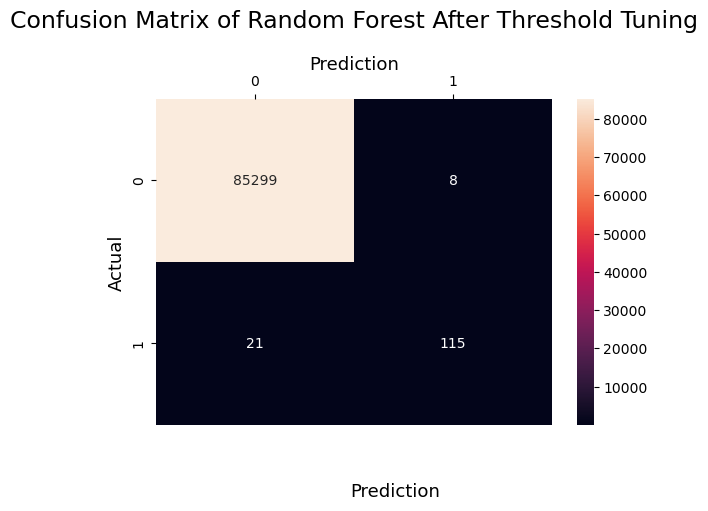

In [76]:
confusion_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(confusion_rf, 
            annot=True,
            fmt='g', 
            xticklabels=['0','1'],
            yticklabels=['0','1'])
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix of Random Forest After Threshold Tuning', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()

In [77]:
y_pred = (y_pred_proba[:,1]>=best_threshold_pr_xgb).astype(int)

In [79]:
print(f"Accuracy score of XGB: {accuracy_score(y_test,y_pred)}")
print(f"Accuracy score of Random Forest: {accuracy_score(y_test,y_pred_rf)}")

Accuracy score of XGB: 0.9996722961506501
Accuracy score of Random Forest: 0.9996605924417448
